Accuracy: 1.00


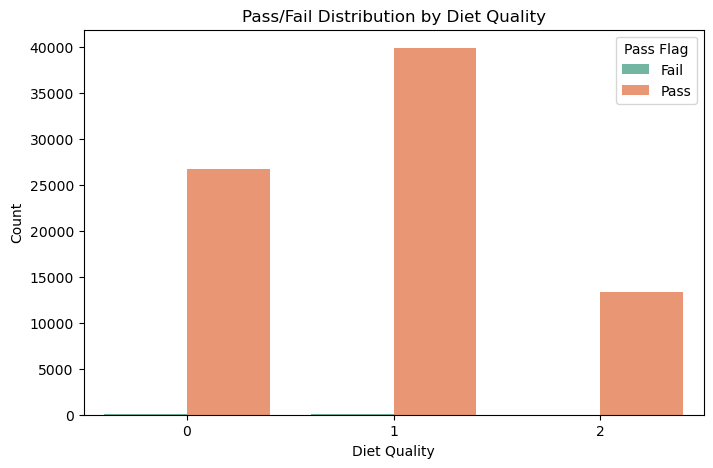

In [1]:
# importing lib
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
df = pd.read_csv("dataset_performance.csv")

# Create binary target: 1 = Pass, 0 = Fail
df['pass_flag'] = (df['exam_score'] >= 50).astype(int)

# Select categorical features for this example
selected_columns = ['diet_quality', 'part_time_job', 'learning_style', 'pass_flag']
df = df[selected_columns].dropna()  # drop rows with missing values

# Label encode the categorical features
label_encoders = {}
for column in selected_columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

# Define features and target
X = df[['diet_quality', 'part_time_job', 'learning_style']]
y = df['pass_flag']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train the Naive Bayes model
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)

# Predict
y_pred = nb_classifier.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Visualizations ['Diet Quality']
plt.figure(figsize=(8, 5))
sns.countplot(x='diet_quality', hue='pass_flag', data=df, palette='Set2')
plt.xlabel('Diet Quality')
plt.ylabel('Count')
plt.title('Pass/Fail Distribution by Diet Quality')
plt.legend(title='Pass Flag', labels=['Fail', 'Pass'])
plt.show()


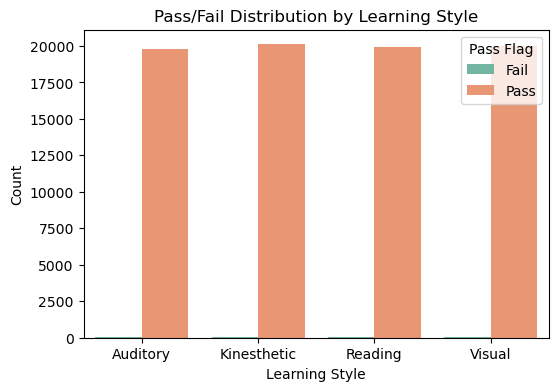

In [2]:

# Visualizations ['Learning Style']
plt.figure(figsize=(6, 4))
sns.countplot(x='learning_style', hue='pass_flag', data=df, palette='Set2')
plt.xlabel('Learning Style')
plt.ylabel('Count')
plt.title('Pass/Fail Distribution by Learning Style')
plt.legend(title='Pass Flag', labels=['Fail', 'Pass'])
plt.xticks(ticks=[0, 1, 2, 3], labels=label_encoders['learning_style'].classes_)
plt.show()



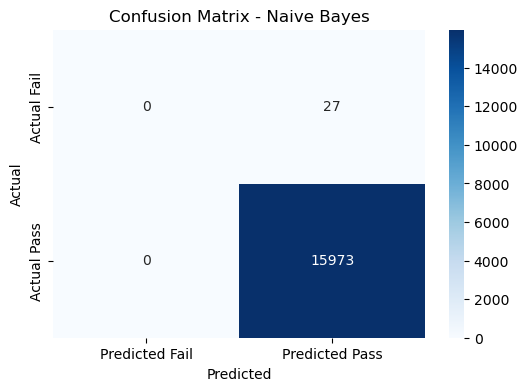

In [3]:

# Confusion Matrix
# Visualizations ['Confusion Matrix']
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Predicted Fail', 'Predicted Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()
